# Which frames are worth an API call

A vision call costs ~0.5s and ~900 tokens. Most frames from a fixed camera are worth nothing:
the room is the same, only sensor grain, the IR illuminator and JPEG re-encoding moved the pixels.

This gate answers one question locally, in ~5 ms: **has anything changed since the last frame we
actually paid for?** If not, no call — reuse the previous answer.

Two rules make it work:

- compare against the **anchor** (last frame sent to the model), not the previous frame —
  otherwise a slow event creeps past the threshold one small step at a time and never fires;
- score the **loudest tile**, not the frame average — a cat is a few percent of a wide shot,
  and an average drowns it in grain.

Why these and not the obvious alternatives is measured in `gate.ipynb`. This notebook is just the result.

In [2]:
import base64
from io import BytesIO
from pathlib import Path
from time import perf_counter

from IPython.display import HTML, display
from PIL import Image, ImageChops, ImageFilter, ImageStat

DATA_DIR = Path("data") if Path("data").is_dir() else Path("../data")

GATE_SIZE = (128, 72)  # fixed, not aspect-preserving: camera frames differ by a few pixels
GRID = 8               # 8x8 board of tiles
BLUR = 2               # gaussian radius, in gate pixels — kills sensor grain
THRESHOLD = 6.6        # grey levels in the loudest tile; calibrated on this footage in gate.ipynb


def load(name: str) -> Image.Image:
    return Image.open(DATA_DIR / name).convert("L").resize(GATE_SIZE)


def tiles(a: Image.Image, b: Image.Image) -> list:
    """Per-tile change between two frames, after blurring and matching brightness."""
    blur = ImageFilter.GaussianBlur(BLUR)
    first, second = a.filter(blur), b.filter(blur)
    shift = ImageStat.Stat(second).mean[0] - ImageStat.Stat(first).mean[0]
    second = second.point(lambda p: max(0, min(255, p - shift)))  # a lamp moves the mean, not the room
    difference = ImageChops.difference(first, second)
    width, height = difference.size
    return [
        [
            ImageStat.Stat(difference.crop((x * width // GRID, y * height // GRID,
                                            (x + 1) * width // GRID, (y + 1) * height // GRID))).mean[0]
            for x in range(GRID)
        ]
        for y in range(GRID)
    ]


def change_score(a: Image.Image, b: Image.Image) -> float:
    return max(max(row) for row in tiles(a, b))


def should_send(frame: Image.Image, anchor: Image.Image) -> bool:
    """Is this frame different enough from the last one we paid for?"""
    return change_score(anchor, frame) > THRESHOLD


_a, _b = load("1.png"), load("3.png")
started = perf_counter()
change_score(_a, _b)
scoring = (perf_counter() - started) * 1000
started = perf_counter()
load("1.png")
decoding = (perf_counter() - started) * 1000
print(f"scoring a frame: {scoring:.1f} ms · decoding the 2000px PNG first: {decoding:.0f} ms "
      f"· one API call: ~470 ms")

scoring a frame: 4.9 ms · decoding the 2000px PNG first: 61 ms · one API call: ~470 ms


In [3]:
# A minute of camera: the same room, junk frames in between, and two real changes.

def noisy(image: Image.Image, sigma: int = 8) -> Image.Image:
    return ImageChops.add(image, Image.effect_noise(image.size, sigma), scale=1, offset=-128)


def brighter(image: Image.Image, delta: int = 20) -> Image.Image:
    return image.point(lambda p: min(255, p + delta))


def recompressed(image: Image.Image, quality: int = 40) -> Image.Image:
    buffer = BytesIO()
    image.save(buffer, "JPEG", quality=quality)
    return Image.open(BytesIO(buffer.getvalue())).convert("L")


one, two, three = load("1.png"), load("2.png"), load("3.png")

# (label, frame, should the model see it?)
SEQUENCE = [
    ("first frame", one, True),                        # nothing to compare against yet
    ("sensor grain", noisy(one), False),
    ("IR gain steps up", brighter(one), False),
    ("re-encoded", recompressed(one), False),
    ("cat moved on the chair", two, True),
    ("sensor grain again", noisy(two), False),
    ("cat is on the table", three, True),
]

AMPLIFY = 8       # differences are a few grey levels; multiply or you see a black rectangle
TILE_SCALE = 12   # one colour scale everywhere: green 0 -> red 12+


def thumb(image: Image.Image, width: int = 150) -> str:
    resized = image.resize((width, round(image.height * width / image.width)), Image.NEAREST)
    buffer = BytesIO()
    resized.convert("RGB").save(buffer, "JPEG", quality=60)
    return f'<img src="data:image/jpeg;base64,{base64.b64encode(buffer.getvalue()).decode()}" width="{width}">'


def difference_view(a: Image.Image, b: Image.Image) -> str:
    blur = ImageFilter.GaussianBlur(BLUR)
    first, second = a.filter(blur), b.filter(blur)
    shift = ImageStat.Stat(second).mean[0] - ImageStat.Stat(first).mean[0]
    second = second.point(lambda p: max(0, min(255, p - shift)))
    return thumb(ImageChops.difference(first, second).point(lambda p: min(255, p * AMPLIFY)))


def board_view(board: list) -> str:
    image = Image.new("RGB", (GRID, GRID))
    image.putdata([(round(255 * min(1, v / TILE_SCALE)), round(200 * (1 - min(1, v / TILE_SCALE))), 60)
                   for row in board for v in row])
    return thumb(image)


print(len(SEQUENCE), "frames,", sum(send for *_, send in SEQUENCE), "of them worth a call")

7 frames, 3 of them worth a call


,frame,difference from anchor x8,tiles
first frameAPI CALL,,,
sensor grainskippedloudest tile 1.90 vs 6.6,,,
IR gain steps upskippedloudest tile 2.64 vs 6.6,,,
re-encodedskippedloudest tile 1.08 vs 6.6,,,
cat moved on the chairAPI CALLloudest tile 17.03 vs 6.6,,,
sensor grain againskippedloudest tile 1.81 vs 6.6,,,
cat is on the tableAPI CALLloudest tile 19.18 vs 6.6,,,

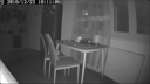
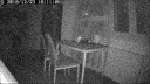
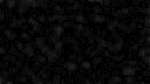
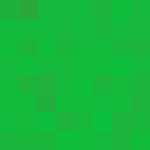
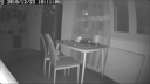
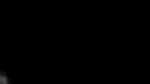
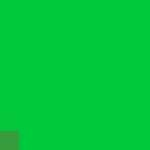
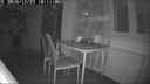
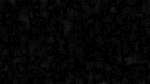
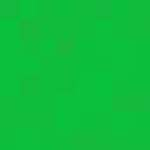
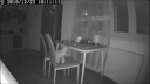
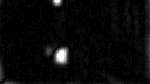
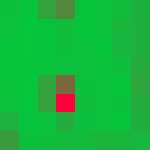
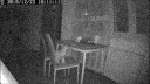
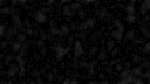
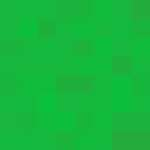
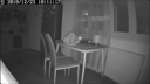
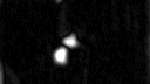
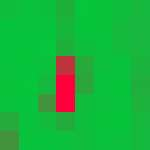

In [4]:
# Walk the sequence. The anchor only moves when a frame is actually sent.
anchor, sent, rows = None, 0, ""
for label, frame, expected in SEQUENCE:
    score = 0.0 if anchor is None else change_score(anchor, frame)
    send = anchor is None or score > THRESHOLD
    assert send == expected, f"{label}: gate said {send}"
    colour = "#2e7d32" if send else "#999"
    rows += (
        f"<tr style='border-top:1px solid #ddd'>"
        f"<td style='padding:6px'><b>{label}</b><br>"
        f"<span style='color:{colour}'>{'API CALL' if send else 'skipped'}</span>"
        f"{'' if anchor is None else f'<br><span style=color:#888>loudest tile {score:.2f} vs {THRESHOLD}</span>'}</td>"
        f"<td style='padding:6px'>{thumb(frame)}</td>"
        f"<td style='padding:6px'>{'' if anchor is None else difference_view(anchor, frame)}</td>"
        f"<td style='padding:6px'>{'' if anchor is None else board_view(tiles(anchor, frame))}</td></tr>"
    )
    if send:
        anchor, sent = frame, sent + 1

display(HTML(
    "<table style='border-collapse:collapse'><tr><th></th><th style='padding:6px'>frame</th>"
    f"<th style='padding:6px'>difference from anchor x{AMPLIFY}</th>"
    "<th style='padding:6px'>tiles</th></tr>" + rows + "</table>"
    f"<p><b>{sent} of {len(SEQUENCE)}</b> frames reached the model — "
    f"{(len(SEQUENCE) - sent) * 0.47:.1f}s and ~{(len(SEQUENCE) - sent) * 900} tokens not spent.<br>"
    f"<span style='color:#888'>green board = nothing moved; one red tile = something did, "
    f"and that is the frame worth asking about.</span></p>"
))

## Before pointing this at a live camera

- **Recalibrate `THRESHOLD`.** Record a few minutes of an empty room, take the highest score the
  gate produces on it, and put the threshold above that. 6.6 is this footage, not a law.
- **Heartbeat.** Send one frame every N minutes regardless — the gate can say "nothing changed",
  never "the event did not happen".
- **Cooldown.** After a call fires, stay quiet for a few seconds; motion arrives in bursts and
  every frame of a burst says the same thing.
- **Known ceiling.** If the camera itself gets bumped, every pixel moves and the gate fires on
  nothing. Fixable by searching for the best small shift before scoring (~11 ms); worth it only
  if the camera actually moves.